# Team Answers: Final_Project_Group 1

Workshop: Performance Metrics Classification (MNIST). This notebook answers every "To the student" talking point in the instructor's notebook (`PerformanceMetricsClassification.ipynb`). Each team member's work sits under a header with their name. All reusable code is implemented as class methods in `Individual_notebooks/src/`, and the notebook only imports those classes and calls their methods.

| # | Talking point (original notebook) | Answered by |
|---|---|---|
| 1 | What is a classification problem, and what is a classifier? | Antonio |
| 2 | Meaning of the Boolean values in `y_train_5`, and why `X` was not changed | Antonio |
| 3 | Which image is `some_digit` and what its prediction means | Antonio |
| 4 | `cross_validate`: `cv`, number of trainings, `fit_time`, `score_time`, `test_score` | Sultan |
| 5 | Accuracy: first fold, 90% handwritten rule, SGDClassifier vs the rule | Sultan |
| 6 | `DummyClassifier` accuracy and comparison | Sultan |
| 7 | Fashion-MNIST exercise | Eche |
| 8 | `confusion_matrix`: arguments, output, meaning of the values | Eche |
| 9 | Security drone: precision and recall | John |
| 10 | Recall in Python code | John |
| 11 | F1 score in Python code from TP, FP and FN | John |
| 12 | High precision vs high recall: real-world cases | Antonio |
| 13 | Effect of the threshold on precision and recall, and the intuition | John |

The cross-validation fold research prompt is answered by Sultan.

### Imports and setup

The helper classes live in the `src` folder inside `Individual_notebooks`. The imports below work from the repository root and also from inside `Individual_notebooks`.

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix, f1_score


from Individual_notebooks.src.mnist_viewer import MnistViewer
from Individual_notebooks.src.cross_val_report import CrossValReport
from Individual_notebooks.src.fashion_analysis import FashionAnalysis
from Individual_notebooks.src.metrics_calculator import MetricsCalculator


_IncompleteInputError: incomplete input (2480030083.py, line 12)

## Antonio

**Section:** Classification, preprocessing, training and precision vs recall cases

Antonio answers the classification definitions, explains the Boolean target `y_train_5` and why `X` is unchanged, shows what `some_digit` is and what the model predicts for it, and closes with the precision vs recall trade-off cases.

**Helper class:** `MnistViewer` in `Individual_notebooks/src/mnist_viewer.py`

Load MNIST through the helper class. The cells below reuse `viewer`.

In [2]:
viewer = MnistViewer()
viewer.load_data()

Loaded 70,000 images with 784 pixels each.


### Classification

**Question:** Summarize in your own words, based on the Wikipedia content and potentially additional sources: What are we trying to solve in a classification problem?

**Answer:**

A classification problem asks which predefined category an observation belongs to, based on its features. In this workshop, the features are the pixel intensities of handwritten digit images. The original task has ten possible classes, from 0 to 9. We simplify it into a binary question: “Does this image represent a 5?” The two classes become “5” and “not 5.”

Sources: [Wikipedia — Statistical classification](https://en.wikipedia.org/wiki/Statistical_classification), [scikit-learn — Getting Started](https://scikit-learn.org/stable/getting_started.html).

**Question:** What is a classifier?

**Answer:**

A classifier is an algorithm or function that maps input features to a class label. In our example, SGDClassifier learns from images and their binary labels. After training, it uses an image’s pixel values to predict True for “5” or False for “not 5.”

Sources: Wikipedia — Statistical classification, scikit-learn — Getting Started.

### Preprocessing

**Question:** What do the Boolean values (`True` and `False`) stand for in the target `y_train_5`?

**Answer:**

The expression y_train == "5" creates a Boolean target for each training image. True means the original label is "5". False means the original label is any other digit. These values are the known training targets, not the model’s predictions.

In [3]:
viewer.prepare_data()


,sample_index,original_label,is_five
0,0,5,True
1,1,0,False
2,2,4,False
3,3,1,False
4,4,9,False


**Question:** Why wasn't `X` changed as well?

**Answer:**

`X` contains the image pixels, which remain useful for deciding whether an image represents a 5. We changed the question we want the model to answer, so we changed the target labels rather than the input images. Each image still has 784 pixel features. The original notebook splits `X` into training and test subsets, but does not change its pixel values when converting the targets to binary labels.

### Training a model

**Question:** Which image does `some_digit` stand for? (scroll above if needed)

**Answer:**

When the original notebook is executed from top to bottom, the last assignment before prediction is some_digit = X[2]. Therefore, it refers to the third image because Python indexing starts at zero. Although an earlier cell assigns X[25001], the later assignment replaces it. Our visualization uses index 2 and confirms that its actual label is "4".

**Visual:** Show the some_digit image with its label and the model's prediction.

In [4]:
viewer.train_model()
viewer.plot_digit(index=2).show()

Training complete: the model predicts whether a digit is 5.
Sample index: 2
Actual digit: 4
Actual binary target (is 5): False
Predicted binary target: False (not 5)


**Question:** What is the meaning of the resulting Boolean value (`True` and `False`)?

**Answer:**

A prediction of True means the model classifies the image as a 5. A prediction of False means it classifies the image as not a 5. For X[2], the model returned False, which agrees with its actual label of "4". This is a true negative. The model did not identify the digit specifically as 4; it only rejected the positive class, 5. Because this sample belongs to the training set, this result illustrates prediction but does not establish performance on unseen data.

### Precision vs recall: real-world cases

**Question:** For a medical diagnostics classifier used as a first indicator, what would be better, a high precision or a high recall?

**Answer:**

For the hypothetical first-stage screening system described in the question, I would prioritize high recall. The positive class is “condition present,” and a false negative means missing someone who has the condition and might not be referred for further assessment. High recall reduces the proportion of actual cases missed. Lower precision would create more false alarms and additional assessments, so those costs would still need to be considered.

**Question:** Likewise, what would be better to optimize for when an ML classifier should highlight the best investment opportunities in a stock exchange?

**Answer:**

I would prioritize high precision if the purpose is to produce a selective shortlist of investment opportunities and acting on a false positive is costly. The positive class must first be defined, for example as an investment exceeding a specified return over a fixed period. High precision means a larger proportion of flagged opportunities actually meet that definition. Lower recall means missing some good opportunities. This choice depends on the costs of mistakes; precision alone does not measure profitability or the size of potential losses.

**Question:** Add a real-world case where a high recall is desired, even at the expense of a lower precision.

**Answer:**

A factory could prioritize high recall when screening products for potentially dangerous defects before a human inspection. The positive class is “defective product.” A false negative allows a defective item to pass the screening, while a false positive sends an acceptable item for unnecessary inspection. If missing a dangerous defect is more costly than inspecting an extra item, higher recall is preferable even with lower precision.

**Question:** Add a real-world case where a high precision is preferred, at the expense of a lower recall.

**Answer:**

An email system that automatically deletes messages classified as spam should prioritize high precision for the spam class. A false positive would delete a legitimate message, potentially losing important information. Lower recall would allow some spam into the inbox, but that may be preferable to deleting legitimate messages. The acceptable tradeoff could differ if messages were only placed in a recoverable spam folder.

## Sultan

**Section:** cross_validate, accuracy, DummyClassifier and cross-validation folds

Sultan picks up from the trained model and explains how `cross_validate` evaluates it, what the accuracy numbers say, and how the `DummyClassifier` and the handwritten rule compare.

**Helper class:** `CrossValReport` in `Individual_notebooks/src/cross_val_report.py`

Run the 3-fold cross-validation for the `SGDClassifier` and the `DummyClassifier` once. The cells below reuse `report`.

In [5]:
report = CrossValReport(cv=3).load_data().run()
report.results_table()

,fold,SGDClassifier,DummyClassifier
0,Fold 1,0.95035,0.90965
1,Fold 2,0.96035,0.90965
2,Fold 3,0.96040,0.90965


### cross_validate

**Question:** Describe in your own words what the `cv` argument is for.

**Answer:**

cv tells the model how many parts the training data should be divided into for cross-validation. With cv=3, the data is split into 3 folds. The model trains on 2 folds and tests on the remaining fold. This happens 3 times so that each fold gets used as the test set once.

**Question:** How many times has the model been trained?

**Answer:**
The model has been trained 3 times, once for each fold. Since there are 60,000 training images, each time it uses 40,000 images for training and 20,000 images for testing.

**Question:** How is the value of `cv` related to the output of this function?

**Answer:**

The number of folds determines how many results we get. Since cv=3, fit_time, score_time, and test_score each have 3 values, one for each fold.

**Question:** What do `fit_time`, `score_time` and `test_score` stand for?

**Answer:**

- fit_time is how long the model takes to train for each fold.
- score_time is how long it takes to make predictions and calculate the score.
- test_score is the accuracy of the model on the test data for each fold.

### Accuracy

**Question:** Provide a textual description of the accuracy result for the first fold, e.g. "out of 100 digits, XYZ were correctly predicted, while ZYX were incorrectly predicted".

**Answer:**

In the first test fold, there were 20,000 digits. The model correctly predicted 19,007 of them and got 993 wrong, giving an accuracy of 95.04%.

The calculation is:

0.95035 × 20,000 = 19,007

In [6]:
print(report.describe_fold(fold=0))

Fold 1: out of 20,000 digits, 19,007 were correctly predicted, while 993 were incorrectly predicted (accuracy = 95.03%).


**Question:** Given the uniform distribution of samples across all 10 digits, and that the classifier classifies one of them versus all the others (`5` versus all others), what would be a simple handwritten rule to achieve 90% accuracy?

**Answer:**

A simple rule would be to always predict that the digit is not a 5. Since around 10% of the digits are 5s, this would still give about 90% accuracy. The problem is that the rule would never actually detect a 5.

**Question:** How would you describe the goodness of classification of the `SGDClassifier` versus the expected accuracy of such a handwritten rule? (a sentence or two)

**Answer:**

The SGDClassifier gets around 95.7% accuracy on average, while the simple rule gets around 90%. So the SGDClassifier is clearly better, although the improvement is not as big as it might seem because the simple rule already gets around 90% by just ignoring all the 5s.

### DummyClassifier

**Question:** What is the accuracy of the `DummyClassifier`?

**Answer:**

The DummyClassifier gets about 90.965% accuracy on each fold. This is because it always predicts "not 5", and around 9% of the digits in the dataset are 5s.

In [7]:
print(report.dummy_results["test_score"])

[0.90965 0.90965 0.90965]


**Question:** How does it compare to the handwritten rule you suggested above, and to the `SGDClassifier`?

**Answer:**

The DummyClassifier gives almost the same result as my simple handwritten rule, around 90–91%. The SGDClassifier is about 5 percentage points higher, with accuracy around 95–96%.

This shows why accuracy by itself can be misleading. A model can get a high accuracy score without actually detecting any 5s. Looking at precision and recall gives us a better idea of how well the SGDClassifier is actually detecting 5s. Its precision is 0.84 and its recall is 0.65.

**Visual:** Grouped bar chart of accuracy per fold, SGDClassifier next to DummyClassifier.

In [8]:
report.plot_accuracy_per_fold()

### Cross-validation folds (research prompt)

**Question:** Research what a cross-validation fold is and explain it in your own words.

**Answer:**

A cross-validation fold is basically one part of the dataset. The dataset is divided into k parts, and each part gets a turn being used for testing while the other parts are used for training.

This means every sample gets tested once. At the end, the scores from all the folds can be averaged to get a more reliable idea of how the model performs.

For cv=3, the 60,000 images are divided into 3 folds, so each fold contains 20,000 images.

## Eche

**Section:** Fashion-MNIST exercise and confusion matrix

Eche repeats the full MNIST process on Fashion-MNIST (get, preprocess, train, evaluate) and then explains the confusion matrix and the two matrices shown in the original notebook.

**Helper class:** `FashionAnalysis` in `Individual_notebooks/src/fashion_analysis.py`

### Exercise: Fashion-MNIST data set

**Question:** Get the Fashion-MNIST data set (the fetch cell is in the original notebook).

In [9]:
fashion_mnist = fetch_openml(
    "Fashion-MNIST",
    version=1,
    as_frame=False,
    parser="auto",
    n_retries=5,
    delay=2
)

X_fashion, y_fashion = fashion_mnist.data, fashion_mnist.target

In [10]:
print("X_fashion shape:", X_fashion.shape)
print("y_fashion shape:", y_fashion.shape)
print("First 10 labels:", y_fashion[:10])

X_fashion shape: (70000, 784)
y_fashion shape: (70000,)
First 10 labels: ['9' '0' '0' '3' '0' '2' '7' '2' '5' '5']


**Visual:** Grid of sample Fashion-MNIST images with their labels.

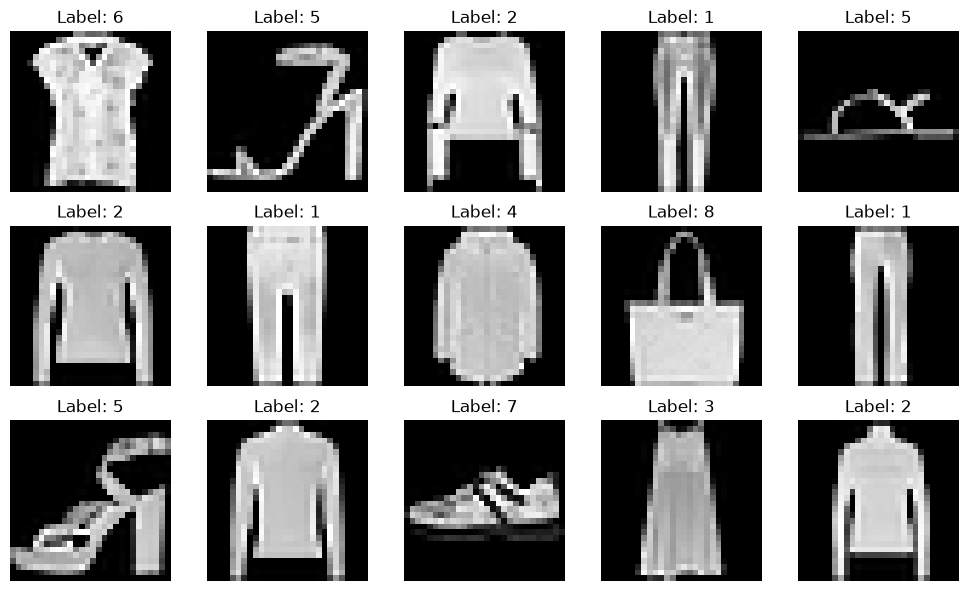

In [11]:
FashionAnalysis.plot_samples(X_fashion, y_fashion)

**Question:** Preprocess the data set (split into train and test, create the binary target). Which clothing category did you choose as the positive class, and why?

**Answer:**

I used the same preprocessing structure as the MNIST example: the first 60,000 observations are used for training and the remaining 10,000 are used for testing. I converted the original 10-class Fashion-MNIST target into a binary target.

I chose **Sneaker** as the positive class (`label = "7"`). The reason is that Sneaker is a clearly defined clothing category and makes the binary task easy to interpret: `True` means the image is a sneaker and `False` means it is another Fashion-MNIST category. This also follows the original notebook's approach of selecting one class of interest and grouping all other classes into the negative class.

In [12]:
X_fashion_train, X_fashion_test = X_fashion[:60000], X_fashion[60000:]
y_fashion_train, y_fashion_test = y_fashion[:60000], y_fashion[60000:]

positive_class = '7'  # Sneaker
y_fashion_train_binary, y_fashion_test_binary = FashionAnalysis.make_binary_targets(
    y_fashion_train, y_fashion_test, positive_class=positive_class
)

print('Positive class: Sneaker (label 7)')
print('Training samples:', len(X_fashion_train))
print('Test samples:', len(X_fashion_test))
print('Positive training samples:', y_fashion_train_binary.sum())
print('Negative training samples:', (~y_fashion_train_binary).sum())

Positive class: Sneaker (label 7)
Training samples: 60000
Test samples: 10000
Positive training samples: 6000
Negative training samples: 54000


**Question:** Train a model.

In [13]:
fashion_sgd_clf = FashionAnalysis.train_sgd(
    X_fashion_train,
    y_fashion_train_binary,
    random_state=42
)

# Fit the model once on the complete training split, matching the MNIST workflow.
fashion_test_predictions = fashion_sgd_clf.predict(X_fashion_test)
print('Model trained successfully.')

Model trained successfully.


**Question:** Evaluate the model (accuracy, DummyClassifier comparison, confusion matrix).

In [14]:
fashion_cv_results, fashion_cv_predictions, fashion_cm = FashionAnalysis.evaluate_model(
    fashion_sgd_clf,
    X_fashion_train,
    y_fashion_train_binary,
    cv=3
)

fashion_dummy, fashion_dummy_results = FashionAnalysis.evaluate_dummy(
    X_fashion_train,
    y_fashion_train_binary,
    cv=3
)

print('SGDClassifier accuracy by fold:', fashion_cv_results['test_score'])
print('SGDClassifier mean accuracy:', fashion_cv_results['test_score'].mean())
print('DummyClassifier accuracy by fold:', fashion_dummy_results['test_score'])
print('DummyClassifier mean accuracy:', fashion_dummy_results['test_score'].mean())
print('Fashion-MNIST confusion matrix:')
print(fashion_cm)

SGDClassifier accuracy by fold: [0.97885 0.97505 0.9635 ]
SGDClassifier mean accuracy: 0.9724666666666666
DummyClassifier accuracy by fold: [0.9 0.9 0.9]
DummyClassifier mean accuracy: 0.9
Fashion-MNIST confusion matrix:
[[53416   584]
 [ 1068  4932]]


**Visual:** Confusion matrix heatmap for the Fashion-MNIST model.

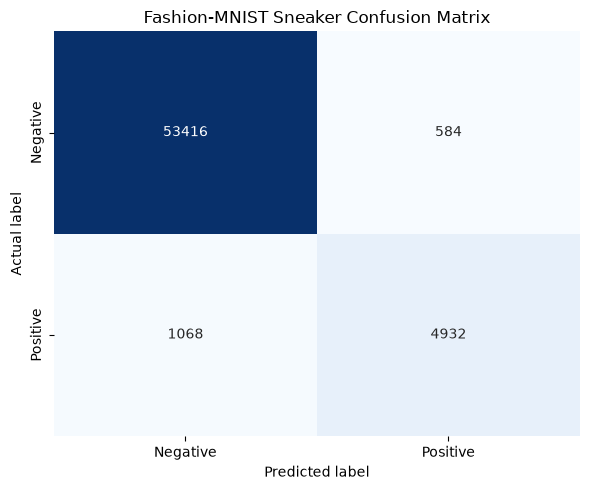

In [15]:
FashionAnalysis.plot_confusion_matrix(fashion_cm, title="Fashion-MNIST Sneaker Confusion Matrix")

**Question:** Are you able to replicate the process? Provide your insights.

**Answer:**

Yes. The process can be replicated using Fashion-MNIST because the dataset has the same basic structure as MNIST: each image is represented by 784 pixel features and each image has a class label.

For this exercise, I selected Sneaker (label 7) as the positive class and converted the original ten-class problem into a binary classification problem. I then trained an SGDClassifier, evaluated it using 3-fold cross-validation, compared its accuracy with a DummyClassifier, and generated a confusion matrix.

The SGDClassifier achieved a mean cross-validation accuracy of approximately 97.26%, while the DummyClassifier achieved 90%. This shows that the SGDClassifier performed better than the baseline. The confusion matrix also provides additional information by showing the true positives, true negatives, false positives, and false negatives.

### Confusion matrix

**Question:** What are the required arguments that the `confusion_matrix` function expects?

**Answer:**

The required arguments are `y_true` and `y_pred`.

- `y_true` is the ground-truth/actual class label for each sample.
- `y_pred` is the predicted class label for each sample.

In this notebook, an example is `confusion_matrix(y_train_5, y_train_pred)`, where `y_train_5` contains the actual binary labels and `y_train_pred` contains the classifier's predictions. Other parameters such as `labels`, `sample_weight`, and `normalize` are optional.

**Question:** What is the output of this function, specifically for a binary classifier such as the one tested here?

**Answer:**

For a binary classifier, `confusion_matrix` returns a **2 × 2 NumPy array**. With the default label ordering, the rows represent the actual classes and the columns represent the predicted classes.

For a binary problem with negative class `0`/`False` and positive class `1`/`True`, the layout is:

`[[TN, FP],`
 ` [FN, TP]]`

where TN is true negative, FP is false positive, FN is false negative, and TP is true positive. Each cell contains the number of samples that fall into that actual/predicted combination.

**Question:** What is the meaning of each value in both of the confusion matrices returned in the original notebook?

**Answer:**

The original notebook returns two binary confusion matrices.

**1. SGDClassifier predictions:**

```text
[[53892,   687],
 [ 1891,  3530]]
```

Using the layout `[[TN, FP], [FN, TP]]`:

- **53,892 TN:** the actual digit was not `5` and the model correctly predicted not `5`.
- **687 FP:** the actual digit was not `5`, but the model incorrectly predicted `5`.
- **1,891 FN:** the actual digit was `5`, but the model incorrectly predicted not `5`.
- **3,530 TP:** the actual digit was `5` and the model correctly predicted `5`.

**2. Perfect predictions in the original notebook:**

```text
[[54579,     0],
 [    0,  5421]]
```

Here the predictions are set equal to the true labels, so every prediction is correct:

- **54,579 TN:** actual not `5`, predicted not `5`.
- **0 FP:** no non-`5` digit was incorrectly predicted as `5`.
- **0 FN:** no actual `5` was missed.
- **5,421 TP:** every actual `5` was correctly predicted as `5`.

The second matrix represents perfect classification because all observations are on the diagonal and both off-diagonal error counts are zero.

**Visual:** Heatmap of the MNIST confusion matrix.

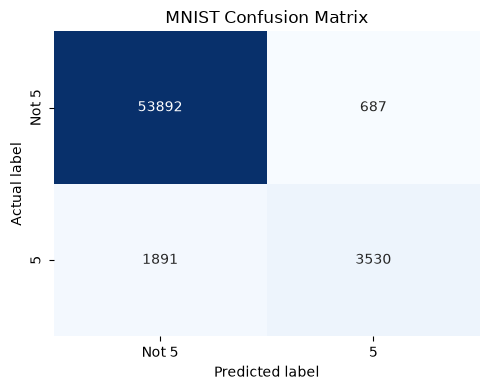

In [16]:
# The original notebook produced this MNIST matrix:
mnist_cm = np.array([[53892, 687], [1891, 3530]])

FashionAnalysis.plot_mnist_confusion_matrix(mnist_cm)

## John

**Section:** Security drone exercise, recall and F1 in code, and thresholds

John turns the confusion-matrix counts into precision, recall and F1 (the security drone exercise plus the MNIST numbers) and then explains how the decision threshold moves precision and recall.

**Helper class:** `MetricsCalculator` in `Individual_notebooks/src/metrics_calculator.py`

### Exercise: Autonomous Security Drone

**Question:** Calculate the Precision of the drone's detection system. Show the fractions you used.

**Answer:**

Precision = TP / (TP + FP)

Precision = 8 / (8 + 4) = 8 / 12 = 0.667

The drone's precision is approximately **66.7%**.

In [17]:
tp = 8
fp = 4
fn = 2
tn = 486

drone_precision = MetricsCalculator.precision(tp, fp)

print(f"Precision = {tp} / ({tp} + {fp})")
print(f"Precision = {drone_precision:.3f}")
print(f"Precision = {drone_precision:.1%}")


Precision = 8 / (8 + 4)
Precision = 0.667
Precision = 66.7%


**Question:** Calculate the Recall of the drone's detection system. Show the fractions you used.

**Answer:**

Recall = TP / (TP + FN)

Recall = 8 / (8 + 2) = 8 / 10 = 0.80

The drone's recall is **80%**.

In [18]:
drone_recall = MetricsCalculator.recall(tp, fn)

print(f"Recall = {tp} / ({tp} + {fn})")
print(f"Recall = {drone_recall:.3f}")
print(f"Recall = {drone_recall:.1%}")


Recall = 8 / (8 + 2)
Recall = 0.800
Recall = 80.0%


**Question:** Explain in your own words what your calculated values for Precision and Recall mean.

**Answer:**

A precision of 66.7% means that when the drone sounded an alarm,
about two-thirds of those alarms were correct. The remaining alarms
were false positives.

A recall of 80% means that the drone detected 8 out of the 10 cases
where a person was actually present. It missed 2 people, which were
false negatives.

In this security scenario, the drone detects most actual intrusions,
but it also produces some unnecessary false alarms.

### Recall in code

**Question:** Similar to the manual calculation of precision, write the Python code for calculating recall.

In [19]:
tp = 3530
fn = 1891

mnist_recall = MetricsCalculator.recall(tp, fn)

print(f"Recall = {tp} / ({tp} + {fn})")
print(f"Recall = {mnist_recall:.4f}")

Recall = 3530 / (3530 + 1891)
Recall = 0.6512


### F1 score in code

**Question:** Using the definition, calculate the F1 score generated in the notebook from True Positives (TP), False Negatives (FN) and False Positives (FP).

In [20]:
tp = 3530
fp = 687
fn = 1891

# Calculate F1 manually
manual_f1 = MetricsCalculator.f1(tp, fp, fn)

print(f"F1 = (2 × {tp}) / ((2 × {tp}) + {fp} + {fn})")
print(f"Manual F1:  {manual_f1:.4f}")

# Verify the same counts using scikit-learn
y_true_check = ([True] * tp) + ([True] * fn) + ([False] * fp)
y_pred_check = ([True] * tp) + ([False] * fn) + ([True] * fp)

sklearn_f1 = f1_score(y_true_check, y_pred_check)

print(f"sklearn F1: {sklearn_f1:.4f}")


F1 = (2 × 3530) / ((2 × 3530) + 687 + 1891)
Manual F1:  0.7325
sklearn F1: 0.7325


### Threshold

**Question:** How do precision and recall change with increasing or decreasing the threshold?

**Answer:**

When the decision threshold is increased, the classifier becomes more strict about predicting a positive result. This will generally increase precision because fewer false positives are accepted, but it can decrease recall because more true positives may be missed.

When the threshold is decreased, the classifier predicts positive more easily. This will generally increase recall because more true positives are detected, but precision may decrease because more false positives can also be included.

**Visual:** Precision and recall against the decision threshold.

In [21]:


y_true_thr, y_scores_thr = MetricsCalculator.prepare_mnist_threshold_data()

figure = MetricsCalculator.plot_precision_recall_threshold(
    y_true_thr,
    y_scores_thr,
    chosen_threshold=3000
)

figure.show()



**Question:** What is the intuition behind this behavior?

**Answer:**

The threshold controls how confident the classifier must be before it predicts that an example belongs to the positive class.

A higher threshold makes the classifier more selective. This can reduce false positives and improve precision, but it can also reject some actual positives, which lowers recall.

A lower threshold makes the classifier less selective. This allows it to catch more actual positives and improve recall, but it may also classify more negative examples as positive, which can lower precision.

The threshold therefore creates a trade-off between precision and recall.

## Team conclusions

- **Accuracy alone can mislead.** On the 5-versus-rest task the `DummyClassifier` already reaches about 91% accuracy by always answering "not 5". The `SGDClassifier` reaches about 95.7%, but its precision (0.84) and recall (0.65) show how many 5s it still misses.
- **The same process works on other data.** On Fashion-MNIST (Sneaker versus the rest) the `SGDClassifier` reaches about 97.3% cross-validated accuracy against 90% for the baseline, and the confusion matrix shows where the errors fall.
- **The confusion matrix is the base of every metric.** Precision, recall and F1 were all calculated from TP, FP and FN, for the security drone (precision 66.7%, recall 80%) and for the MNIST classifier (F1 = 0.7325).
- **The threshold trades precision for recall.** A higher threshold gives fewer but more reliable positives; a lower one catches more positives but admits more false alarms.
- **The right metric depends on the cost of the mistake.** Screening for a medical condition or a dangerous defect favours recall, while auto-deleting spam or shortlisting investments favours precision.